# Logit Lens Demo — BLOOM-560m (Multilingual)

Uses only **transformers + torch + matplotlib**, all pre-installed in Colab.

**Model:** `bigscience/bloom-560m` — 560M params, 46 languages, no token required.

**How logit lens works:**  
BLOOM has 24 transformer layers. We intercept the residual stream after each layer,
project it through the final LayerNorm + unembedding matrix, and read off the
probability distribution — showing what token the model "votes for" at every layer.

**Demos:**
1. Heatmap: top predicted token at every (layer, position)
2. Track a specific token's probability across layers
3. English vs Spanish vs Basque side-by-side

In [ ]:
# Cell 1 — Imports and model (no installs needed)
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "bigscience/bloom-560m"  # 560M params, 46 languages
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float32)
model.eval()

# BLOOM config uses num_hidden_layers instead of n_layer
n_layers = model.config.num_hidden_layers
d_model  = model.config.hidden_size
print(f"BLOOM-560m: {n_layers} layers, d_model={d_model}, vocab={model.config.vocab_size}")

/Users/kailee/code/Kai-Justin-NLP-Project/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 293/293 [00:01<00:00, 249.79it/s, Materializing param=transformer.word_embeddings_layernorm.weight]           

BLOOM-560m: 24 layers, d_model=1024, vocab=250880
Supported languages include: English, Spanish, Basque, French, German, Chinese, Arabic, ...


In [2]:
# Cell 2 — Logit lens function
#
# BLOOM's internal attribute names are the same as GPT-2:
#   model.transformer.h     — list of transformer layers
#   model.transformer.ln_f  — final layer norm
#   model.lm_head           — unembedding matrix
#
# output_hidden_states=True returns a tuple of (n_layers+1) tensors.
# Index 0 = after embedding+positional, 1..24 = after each transformer layer.

def logit_lens(prompt):
    """
    Returns:
        str_tokens : list[str]  input tokens
        top_words  : (n_layers, seq_len) list of top-1 predicted token strings
        top_probs  : (n_layers, seq_len) numpy array of top-1 probabilities
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    str_tokens = [tokenizer.decode([t]) for t in inputs["input_ids"][0]]

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states[1:]  # skip embedding, keep layers 1-24

    top_words = []
    top_probs = np.zeros((n_layers, len(str_tokens)))

    for layer_idx, h in enumerate(hidden_states):
        h = h.squeeze(0)                                    # (seq_len, d_model)
        logits = model.lm_head(model.transformer.ln_f(h))  # (seq_len, vocab)
        probs = logits.softmax(dim=-1)                      # (seq_len, vocab)
        best_prob, best_id = probs.max(dim=-1)              # (seq_len,)

        top_probs[layer_idx] = best_prob.detach().numpy()
        top_words.append([tokenizer.decode([t]) for t in best_id])

    return str_tokens, top_words, top_probs


# Quick sanity check
tokens, words, probs = logit_lens("The Eiffel Tower is in the city of")
print("Input tokens:", tokens)
print("\nTop prediction at LAST token position per layer:")
for i in range(n_layers):
    print(f"  Layer {i+1:2d}: '{words[i][-1]}'  p={probs[i, -1]:.3f}")

Input tokens: ['The', ' Eiffel', ' Tower', ' is', ' in', ' the', ' city', ' of']

Top prediction at LAST token position per layer:
  Layer  1: ' of'  p=1.000
  Layer  2: ' of'  p=1.000
  Layer  3: ' of'  p=1.000
  Layer  4: ' of'  p=1.000
  Layer  5: ' of'  p=1.000
  Layer  6: ' of'  p=0.996
  Layer  7: ' of'  p=0.759
  Layer  8: ' disponibilização'  p=0.946
  Layer  9: ' disponibilização'  p=0.661
  Layer 10: ' disponibilização'  p=0.596
  Layer 11: ' mensonge'  p=0.301
  Layer 12: ' mensonge'  p=0.225
  Layer 13: ' plais'  p=0.346
  Layer 14: ' today'  p=0.271
  Layer 15: ' plais'  p=0.222
  Layer 16: ' francophone'  p=0.340
  Layer 17: ' capitale'  p=0.335
  Layer 18: ' capitale'  p=0.470
  Layer 19: ' capitale'  p=0.586
  Layer 20: ' downtown'  p=0.635
  Layer 21: ' Paris'  p=0.955
  Layer 22: ' Paris'  p=0.918
  Layer 23: ' Paris'  p=0.657
  Layer 24: '.'  p=0.040


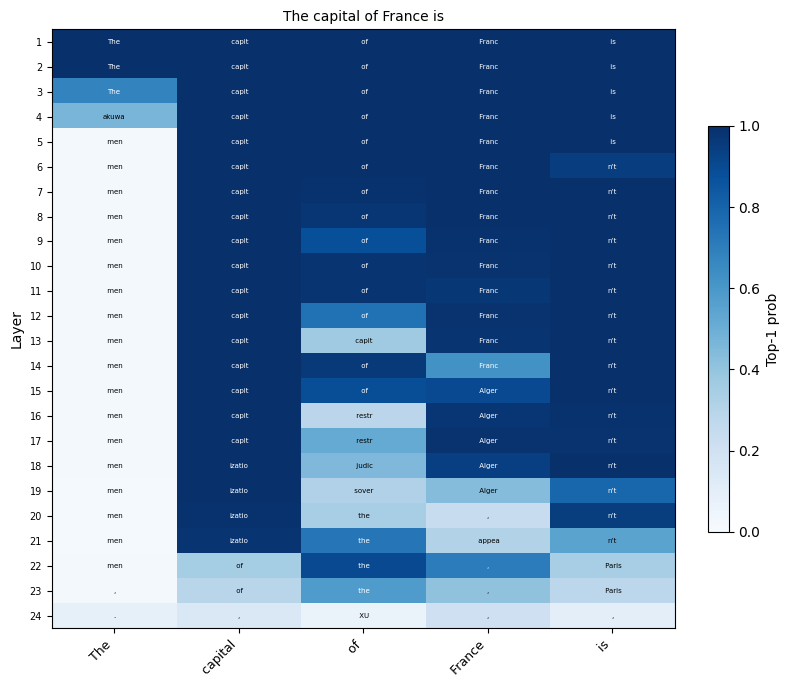

In [3]:
# Cell 3 — Heatmap: top predicted token at every (layer, position)

def plot_logit_lens(prompt, ax=None, title=None):
    tokens, top_words, top_probs = logit_lens(prompt)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.9), 7))

    im = ax.imshow(top_probs, cmap="Blues", aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels([f"{i+1}" for i in range(n_layers)], fontsize=7)
    ax.set_ylabel("Layer")
    ax.set_title(title or prompt, fontsize=10)

    for li in range(n_layers):
        for ti in range(len(tokens)):
            word = top_words[li][ti][:6]
            color = "white" if top_probs[li, ti] > 0.55 else "black"
            ax.text(ti, li, word, ha="center", va="center", fontsize=5, color=color)

    if standalone:
        plt.colorbar(im, ax=ax, label="Top-1 prob", fraction=0.03)
        plt.tight_layout()
        plt.show()
    return im


plot_logit_lens("The capital of France is")

In [4]:
# Cell 4 — Load dataset
#
# Expects three files: english.jsonl, spanish.jsonl, basque.jsonl
# Each line: {"id": ..., "category": ..., "question": ..., "ground_truth": ...}
#
# In Colab: either upload the files directly, or mount Drive and set DATA_DIR.

import json
from pathlib import Path

# ── Path setup ────────────────────────────────────────────────────────────────
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = Path("data")  # adjust if running in Colab with a different path

def load_jsonl(path):
    return [json.loads(line) for line in open(path, encoding="utf-8") if line.strip()]

english = load_jsonl(DATA_DIR / "english.jsonl")
spanish = load_jsonl(DATA_DIR / "spanish.jsonl")
basque  = load_jsonl(DATA_DIR / "basque.jsonl")

# Align by id so every triplet has EN/ES/EU versions of the same question
en_by_id = {d["id"]: d for d in english}
es_by_id = {d["id"]: d for d in spanish}
eu_by_id = {d["id"]: d for d in basque}
common_ids = sorted(set(en_by_id) & set(es_by_id) & set(eu_by_id))

print(f"English: {len(english)} | Spanish: {len(spanish)} | Basque: {len(basque)}")
print(f"Aligned triplets: {len(common_ids)}")
print(f"\nSample (id={common_ids[0]}):")
for lang, store in [("EN", en_by_id), ("ES", es_by_id), ("EU", eu_by_id)]:
    d = store[common_ids[0]]
    print(f"  [{lang}] {d['question']}  →  {d['ground_truth']}")

# ── Subset control ────────────────────────────────────────────────────────────
# N_PER_CATEGORY questions per category per language.
# Set to 20 for the full dataset; reduce to 5 for a quick test run.
N_PER_CATEGORY = 20

English: 60 | Spanish: 60 | Basque: 60
Aligned triplets: 60

Sample (id=factual_1):
  [EN] What is the capital of France?  →  Paris
  [ES] ¿Cuál es la capital de Francia?  →  París
  [EU] Frantziako hiriburua zein da?  →  Paris


In [ ]:
# Cell 5 — Run logit lens over the dataset
#
# For each question we record two things at every layer, at the final token position:
#   1. rank_of_gt  : rank of the ground-truth first token (0 = top prediction)
#   2. top1_prob   : probability of whatever the model's top-1 token is (confidence)
#
# We average these over all questions in each (language, category) group.

def gt_first_token_id(ground_truth):
    """Return the vocab id of the first token of the ground truth string."""
    ids = tokenizer.encode(" " + ground_truth.strip(), add_special_tokens=False)
    return ids[0] if ids else None

def logit_lens_metrics(prompt, gt_token_id):
    """
    Returns two lists of length n_layers:
        ranks  : rank of gt_token_id at the last position (lower = better)
        top1_p : top-1 probability at the last position
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    ranks, top1_probs = [], []
    for h in outputs.hidden_states[1:]:         # skip embedding layer
        h_last = h[0, -1, :]                    # last token, (d_model,)
        logits = model.lm_head(model.transformer.ln_f(h_last))   # (vocab,)
        probs  = logits.softmax(dim=-1)

        top1_probs.append(probs.max().item())

        if gt_token_id is not None:
            rank = (probs.argsort(descending=True) == gt_token_id).nonzero(as_tuple=True)[0].item()
        else:
            rank = -1
        ranks.append(rank)

    return ranks, top1_probs


CATEGORIES = ["math", "factual", "reasoning"]
LANGS = {
    "English": en_by_id,
    "Spanish": es_by_id,
    "Basque":  eu_by_id,
}

# results[lang][cat] = {"ranks": (n_q, n_layers), "top1": (n_q, n_layers)}
results = {lang: {cat: {"ranks": [], "top1": []} for cat in CATEGORIES} for lang in LANGS}

# Build list of (lang_name, store, qid) to process
tasks = []
seen_per_cat = {lang: {cat: 0 for cat in CATEGORIES} for lang in LANGS}
for qid in common_ids:
    cat = en_by_id[qid]["category"]
    if all(seen_per_cat[lang][cat] < N_PER_CATEGORY for lang in LANGS):
        for lang_name, store in LANGS.items():
            tasks.append((lang_name, store, qid, cat))
        for lang_name in LANGS:
            seen_per_cat[lang_name][cat] += 1

total = len(tasks)
print(f"Running logit lens on {total} (question, language) pairs ...\n")

for i, (lang_name, store, qid, cat) in enumerate(tasks):
    item = store[qid]
    gt_id = gt_first_token_id(item["ground_truth"])
    ranks, top1 = logit_lens_metrics(item["question"], gt_id)
    results[lang_name][cat]["ranks"].append(ranks)
    results[lang_name][cat]["top1"].append(top1)

    if (i + 1) % 15 == 0 or i == total - 1:
        print(f"  {i+1}/{total}  [{lang_name} | {cat} | id={qid}]")

print("\nDone.")

Running logit lens on 180 (question, language) pairs ...



In [ ]:
# Cell 6 — Plot: Average rank of ground-truth token by layer
#
# Lower rank = model is closer to predicting the correct answer.
# Rank 0 = model's top prediction IS the ground truth.
# We cap display at rank 500 so outliers don't crush the scale.

lang_styles = {
    "English": ("steelblue",  "o"),
    "Spanish": ("darkorange", "s"),
    "Basque":  ("green",      "^"),
}

layers = list(range(1, n_layers + 1))
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(15, 4), sharey=False)

for ax, cat in zip(axes, CATEGORIES):
    for lang, (color, marker) in lang_styles.items():
        rank_matrix = np.array(results[lang][cat]["ranks"])   # (n_q, n_layers)
        mean_ranks  = rank_matrix.mean(axis=0)
        ax.plot(layers, mean_ranks, marker=marker, color=color,
                label=lang, linewidth=1.8, markersize=4)

    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean rank of GT token  (lower = better)")
    ax.set_xticks(layers[::2])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()   # rank 0 (best) at top

plt.suptitle("Logit Lens — Mean Rank of Ground-Truth Token by Layer\n(BLOOM-560m, full benchmark)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Lang':<10} {'Category':<12} {'Mean rank @ layer 1':>20} {'Mean rank @ layer 24':>22}")
print("-" * 68)
for lang in ["English", "Spanish", "Basque"]:
    for cat in CATEGORIES:
        rm = np.array(results[lang][cat]["ranks"])
        print(f"{lang:<10} {cat:<12} {rm[:, 0].mean():>20.1f} {rm[:, -1].mean():>22.1f}")

In [ ]:
# Cell 7 — Plot: Average top-1 confidence by layer
#
# This shows how "decisive" the model is at each layer regardless of correctness.
# High confidence = model is committed to *some* token.
# Compare with rank plot: high confidence + low rank = correct and confident.

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(15, 4), sharey=True)

for ax, cat in zip(axes, CATEGORIES):
    for lang, (color, marker) in lang_styles.items():
        top1_matrix = np.array(results[lang][cat]["top1"])   # (n_q, n_layers)
        mean_top1   = top1_matrix.mean(axis=0)
        ax.plot(layers, mean_top1, marker=marker, color=color,
                label=lang, linewidth=1.8, markersize=4)

    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean top-1 probability")
    ax.set_xticks(layers[::2])
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Logit Lens — Mean Top-1 Confidence by Layer\n(BLOOM-560m, full benchmark)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Lang':<10} {'Category':<12} {'Mean conf @ layer 1':>20} {'Mean conf @ layer 24':>22}")
print("-" * 68)
for lang in ["English", "Spanish", "Basque"]:
    for cat in CATEGORIES:
        tm = np.array(results[lang][cat]["top1"])
        print(f"{lang:<10} {cat:<12} {tm[:, 0].mean():>20.3f} {tm[:, -1].mean():>22.3f}")

In [ ]:
# Cell 8 — Save all figures to disk for the blog post

import os
os.makedirs("figures", exist_ok=True)

# --- Figure 1: heatmap for a single illustrative English prompt ---
tokens, top_words, top_probs = logit_lens("The capital of France is")
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(top_probs, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(n_layers))
ax.set_yticklabels([f"{i+1}" for i in range(n_layers)], fontsize=8)
ax.set_ylabel("Layer")
ax.set_title("Logit Lens Heatmap: \"The capital of France is\" (BLOOM-560m)", fontsize=11)
for li in range(n_layers):
    for ti in range(len(tokens)):
        word = top_words[li][ti][:6]
        color = "white" if top_probs[li, ti] > 0.55 else "black"
        ax.text(ti, li, word, ha="center", va="center", fontsize=6, color=color)
plt.colorbar(im, ax=ax, label="Top-1 probability", fraction=0.03)
plt.tight_layout()
plt.savefig("figures/fig1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig1_heatmap.png")

# --- Figure 2: GT rank by layer (full dataset) ---
layers = list(range(1, n_layers + 1))
lang_styles = {"English": ("steelblue","o"), "Spanish": ("darkorange","s"), "Basque": ("green","^")}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, cat in zip(axes, CATEGORIES):
    for lang, (color, marker) in lang_styles.items():
        rm = np.array(results[lang][cat]["ranks"])
        ax.plot(layers, rm.mean(axis=0), marker=marker, color=color,
                label=lang, linewidth=1.8, markersize=4)
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean rank of GT token")
    ax.set_xticks(layers[::2])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
plt.suptitle("Figure 2: Mean Rank of Ground-Truth Token by Layer (BLOOM-560m, n=20/category)",
             fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig2_gt_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig2_gt_rank.png")

# --- Figure 3: top-1 confidence by layer (full dataset) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cat in zip(axes, CATEGORIES):
    for lang, (color, marker) in lang_styles.items():
        tm = np.array(results[lang][cat]["top1"])
        ax.plot(layers, tm.mean(axis=0), marker=marker, color=color,
                label=lang, linewidth=1.8, markersize=4)
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean top-1 probability")
    ax.set_xticks(layers[::2])
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Figure 3: Mean Top-1 Confidence by Layer (BLOOM-560m, n=20/category)",
             fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig3_confidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig3_confidence.png")

print("\nAll figures saved to figures/")